# Race Analysis

## Environment setup

In [ ]:
import fastf1 as ff1
from fastf1 import plotting
from fastf1.logger import set_log_level
from matplotlib import pyplot as plt

from plots.laps import plot_driver_lap_time_distributions, plot_lap_time_box_plots
from plots.positions import plot_position_changes
from plots.tyres import plot_tyre_strategy

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

%matplotlib widget

## Aggregating and cleaning data

In [2]:
race = ff1.get_session(2025, "Qatar", "R")
race.load(telemetry=False)

In [3]:
race_laps = race.laps.copy()
race_laps.loc[:, "LapTime_s"] = race_laps.LapTime.dt.total_seconds()

In [4]:
race_push_laps = race_laps.pick_quicklaps().copy()

In [5]:
stints = race_laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"])
stints = stints.count().reset_index()
stints = stints.rename(columns={"LapNumber": "StintLength"})

In [6]:
drivers = [race.get_driver(driver)["Abbreviation"] for driver in race.drivers]

In [7]:
point_finishers = race.drivers[:10]

In [8]:
driver_laps = race_push_laps.pick_drivers(point_finishers)
driver_laps = driver_laps.reset_index()

In [9]:
finishing_order = [race.get_driver(i)["Abbreviation"] for i in point_finishers]

## Analysis

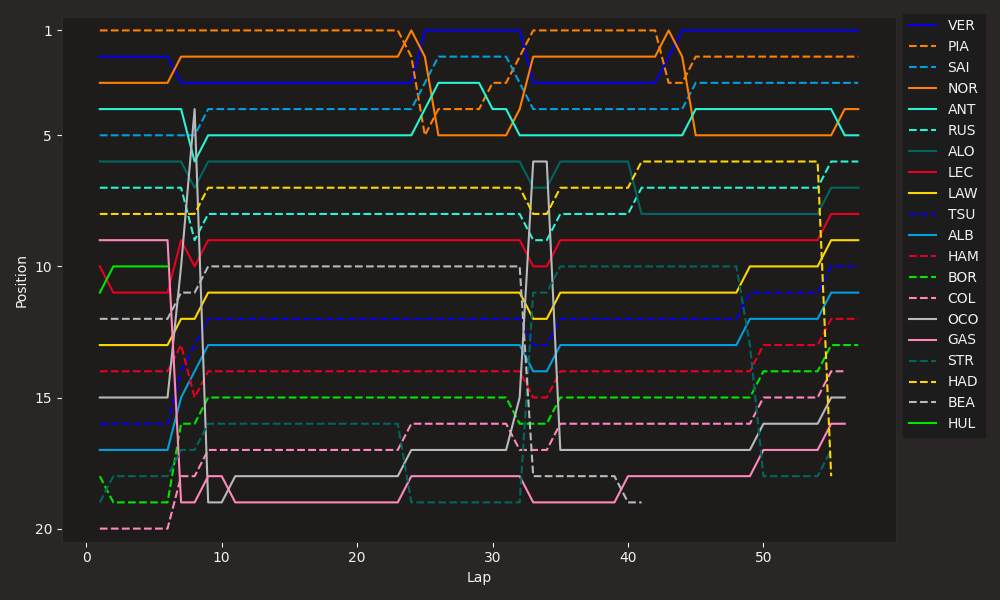

In [10]:
plot_position_changes(race)

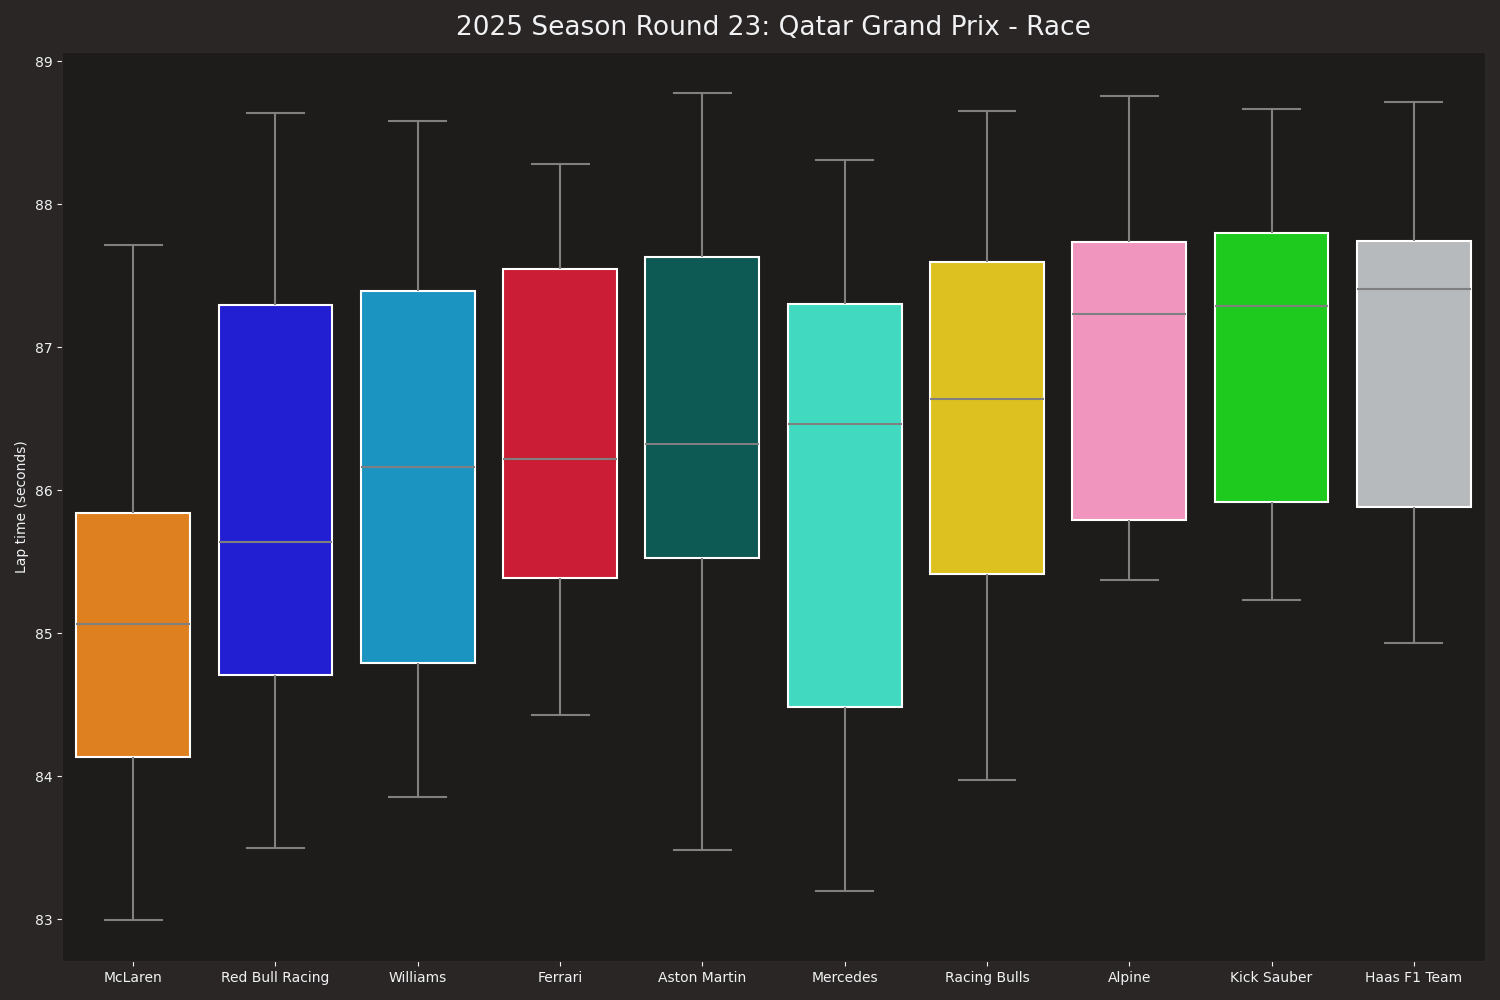

In [11]:
plot_lap_time_box_plots(race_push_laps, race, mode="Team")

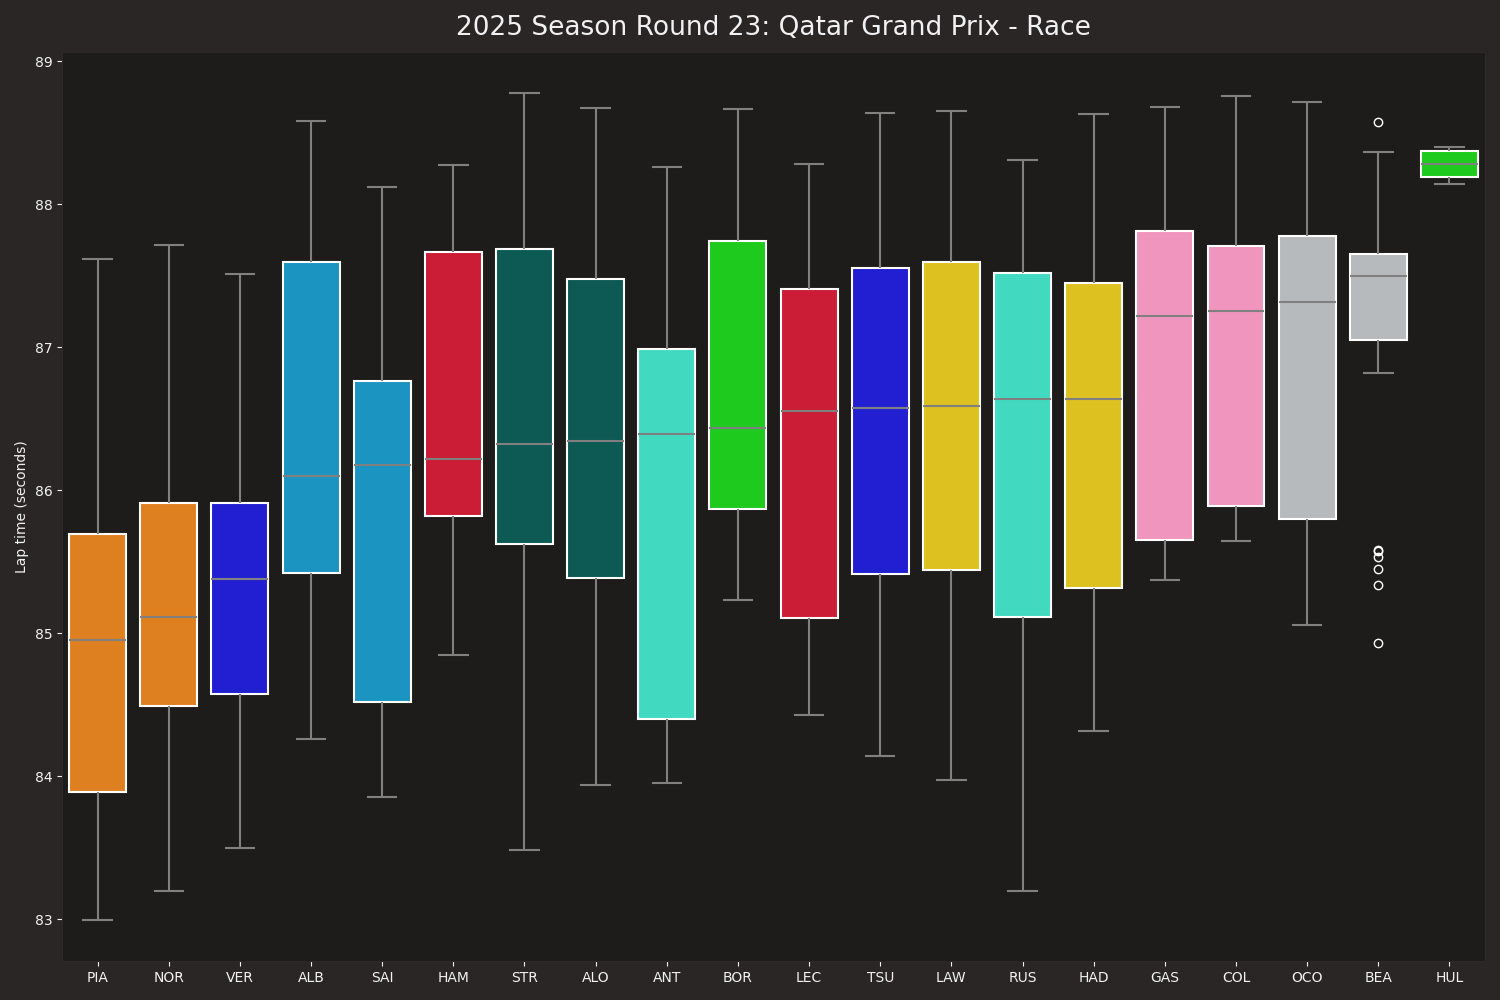

In [12]:
plot_lap_time_box_plots(race_push_laps, race, mode="Driver")

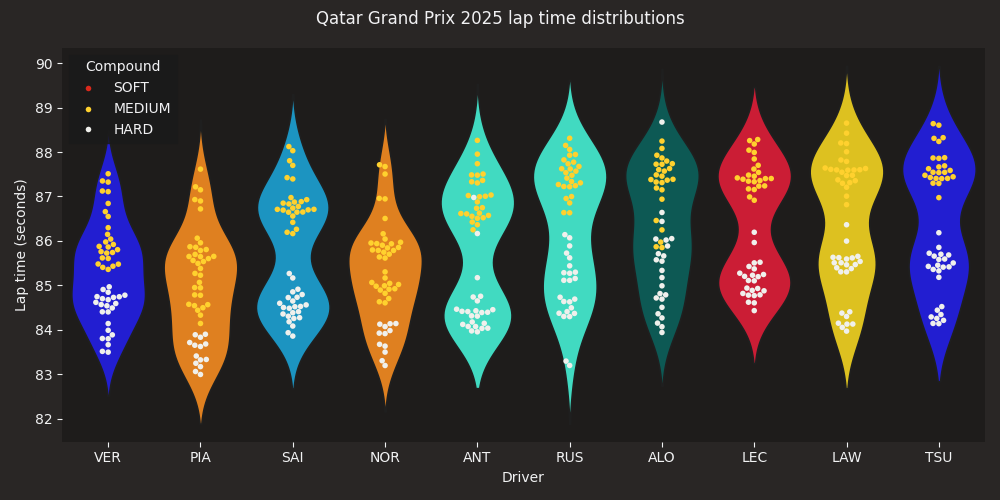

In [13]:
plot_driver_lap_time_distributions(
    driver_laps,
    finishing_order,
    race,
)

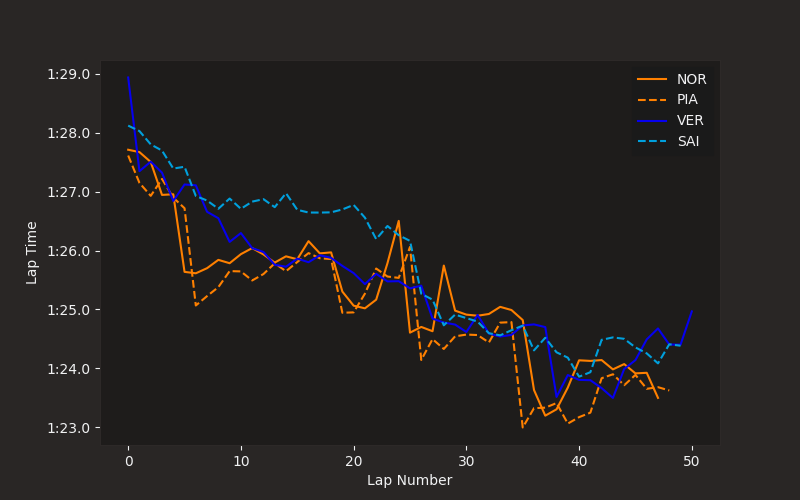

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend()
plotting.add_sorted_driver_legend(ax, race)
plt.show()

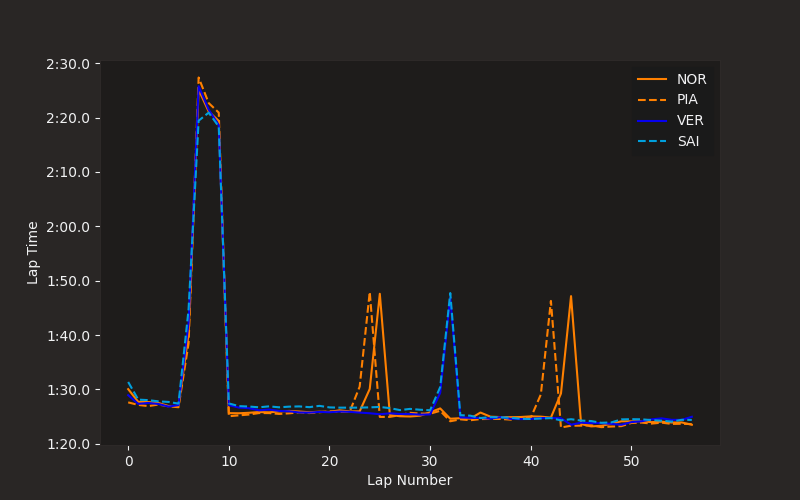

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend()
plotting.add_sorted_driver_legend(ax, race)
plt.show()

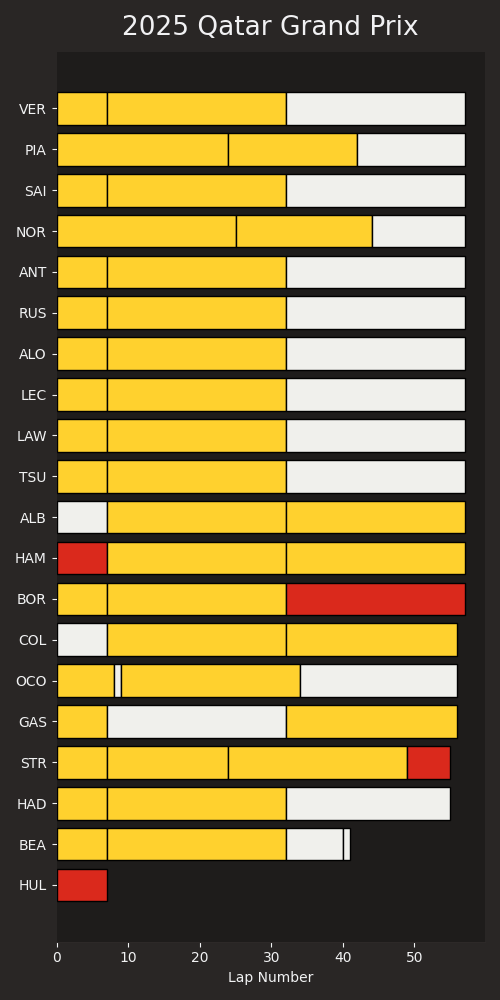

In [16]:
plot_tyre_strategy(drivers, stints, race)